In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [4]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape

(200, 5)

In [7]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [19]:
# Convert Male/Female into numbers
encoder = LabelEncoder()

df["Genre"] = encoder.fit_transform(df["Genre"])

# Select useful columns
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

# Standardize the data
scaler = StandardScaler()

X = scaler.fit_transform(X)

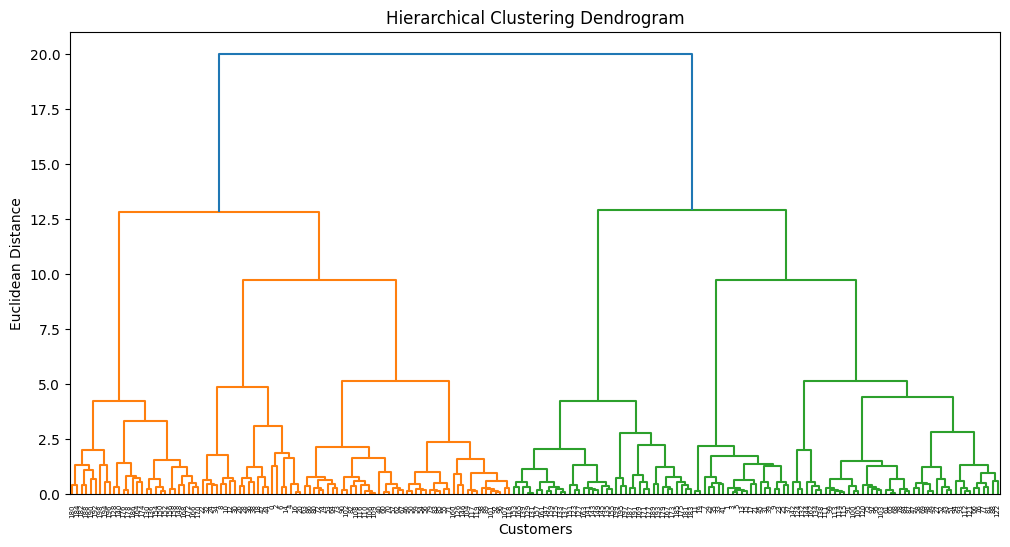

In [20]:
plt.figure(figsize=(12,6))

dendrogram(linkage(X, method="ward"))

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [22]:
k = 5

model = AgglomerativeClustering(

    n_clusters=k,

    metric="euclidean",

    linkage="ward"
)

clusters = model.fit_predict(X)

df["Cluster"] = clusters

print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      1   19                  15                      39        4
1           2      1   21                  15                      81        0
2           3      0   20                  16                       6        4
3           4      0   23                  16                      77        0
4           5      0   31                  17                      40        4


In [23]:
score = silhouette_score(X, clusters)

print("Silhouette Score =", score)

Silhouette Score = 0.39002826186267214


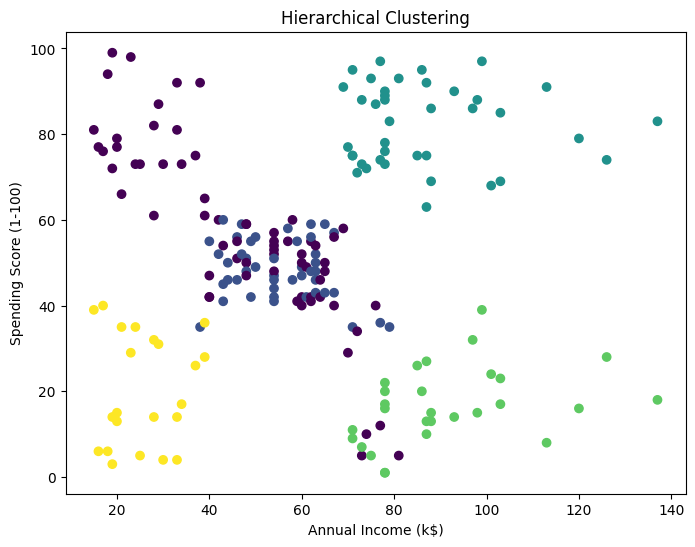

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.show()

In [28]:
df.to_csv("Mall_Customers_Clustered.csv", index=False)

print("File Saved Successfully")

File Saved Successfully
